# M1.Ex4: Modeling Non-linear Patterns

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex4_non-linear.ipynb)
- Raw Dataset: [bmi_and_life_expectancy.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv)

In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import numpy as np

### Step 1. Load the data

In [2]:
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/bmi_and_life_expectancy.csv"
df = pd.read_csv(url)
display(df.head())

,Country,Life expectancy,BMI
0,Afghanistan,52.8,20.62058
1,Albania,76.8,26.44657
2,Algeria,75.5,24.59620
3,Andorra,84.6,27.63048
4,Angola,56.7,22.25083


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
# Feature: BMI  |  Target: Life expectancy
X = df[['BMI']]           # 2D feature matrix
y = df['Life expectancy'] # 1D target vector

print('X (first 5 rows):')
display(X.head())
print('y (first 5 values):')
print(y.head())

X (first 5 rows):


,BMI
0,20.62058
1,26.44657
2,24.59620
3,27.63048
4,22.25083


y (first 5 values):
0    52.8
1    76.8
2    75.5
3    84.6
4    56.7
Name: Life expectancy, dtype: float64


### Step 2.b print the type of each

In [4]:
print('Type of X:', type(X))
print('Type of y:', type(y))

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
print('Target dtype:', y.dtype)
print()
print('The target (Life expectancy) is NUMERICAL — it is a continuous float value.')
print('Therefore, the task is REGRESSION.')

Target dtype: float64

The target (Life expectancy) is NUMERICAL — it is a continuous float value.
Therefore, the task is REGRESSION.


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print('--- Feature Matrix X ---')
print(f'Shape            : {X.shape}')
print(f'Number of samples: {X.shape[0]}')
print(f'Number of columns: {X.shape[1]}')
print()
print('--- Target Vector y ---')
print(f'Shape            : {y.shape}')
print(f'Number of samples: {y.shape[0]}')

--- Feature Matrix X ---
Shape            : (163, 1)
Number of samples: 163
Number of columns: 1

--- Target Vector y ---
Shape            : (163,)
Number of samples: 163


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
summary = df[['BMI', 'Life expectancy']].agg(['min', 'max', 'median', 'mean', 'std'])
print('Distribution Summary:')
display(summary)

Distribution Summary:


,BMI,Life expectancy
min,19.866920,44.500000
max,30.995630,84.600000
median,25.320540,71.800000
mean,24.792378,69.666933
std,2.427900,8.981933


### Step 5. Plot the feature vs the target

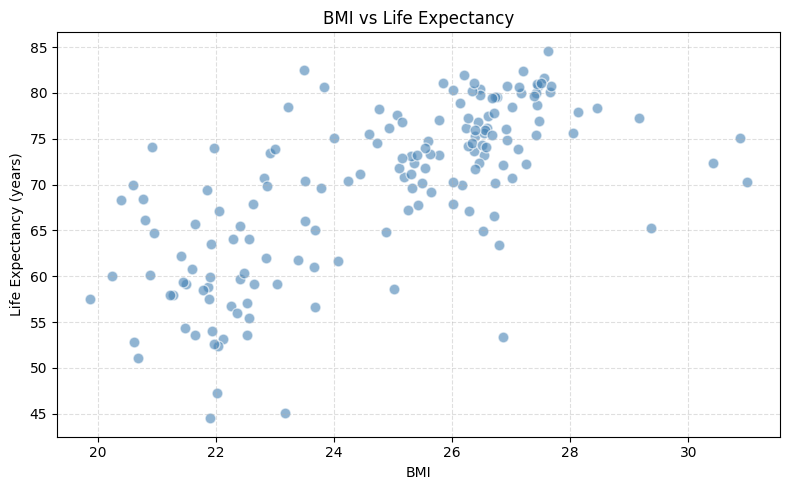

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', alpha=0.6, edgecolors='white', s=60)
plt.xlabel('BMI')
plt.ylabel('Life Expectancy (years)')
plt.title('BMI vs Life Expectancy')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [9]:
correlation = df['BMI'].corr(df['Life expectancy'])
print(f'Pearson Correlation Coefficient: {correlation:.4f}')
print()
print('The relationship appears INCREASING but NON-LINEAR (curved).')
print('At low BMI values, life expectancy is low (underdeveloped countries).')
print('As BMI rises toward a healthy range (~22-27), life expectancy increases sharply.')
print('At very high BMI the trend levels off or slightly decreases.')
print('A simple straight line is not a good fit — a non-linear model is needed.')

Pearson Correlation Coefficient: 0.6808

The relationship appears INCREASING but NON-LINEAR (curved).
At low BMI values, life expectancy is low (underdeveloped countries).
As BMI rises toward a healthy range (~22-27), life expectancy increases sharply.
At very high BMI the trend levels off or slightly decreases.
A simple straight line is not a good fit — a non-linear model is needed.


### Step 7. Make two modeling techniques

First model is just a Linear Regression model: `from sklearn.linear_model import LinearRegression`

Second model: Use one of the previously mentioned methods to model a non-linear relationship

1. `from sklearn.tree import DecisionTreeRegressor`
2. or `from sklearn.preprocessing import PolynomialFeatures`

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

# Model 1: Simple Linear Regression
model_linear = LinearRegression()

# Model 2: Polynomial Regression (degree=3 captures the curve well)
# Pipeline chains PolynomialFeatures (transforms X -> X, X^2, X^3)
# then feeds the expanded features into LinearRegression
model_poly = Pipeline([
    ('poly_features', PolynomialFeatures(degree=3, include_bias=False)),
    ('linear_reg',    LinearRegression())
])

print('Model 1 (Linear)    :', model_linear)
print('Model 2 (Polynomial):', model_poly)

Model 1 (Linear)    : LinearRegression()
Model 2 (Polynomial): Pipeline(steps=[('poly_features',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('linear_reg', LinearRegression())])


### Step 8. Split the dataset into train and test sets

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Total samples     : {len(df)}')
print(f'Training set size : {X_train.shape[0]} samples (80%)')
print(f'Test set size     : {X_test.shape[0]} samples (20%)')

Total samples     : 163
Training set size : 130 samples (80%)
Test set size     : 33 samples (20%)


### Step 9. Train both models on the training set

In [12]:
model_linear.fit(X_train, y_train)
print('Model 1 (Linear) trained successfully!')

model_poly.fit(X_train, y_train)
print('Model 2 (Polynomial degree=3) trained successfully!')

Model 1 (Linear) trained successfully!
Model 2 (Polynomial degree=3) trained successfully!


### Step 10. Evaluate and compare which of the two models score better on the `train` set

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(name, model, X, y):
    y_pred = model.predict(X)
    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    r2   = r2_score(y, y_pred)
    print(f'  {name}')
    print(f'    MAE : {mae:.4f}')
    print(f'    RMSE: {rmse:.4f}')
    print(f'    R²  : {r2:.4f}')
    return r2

print('=== TRAIN SET ===')
r2_linear_train = evaluate('Linear Regression', model_linear, X_train, y_train)
print()
r2_poly_train   = evaluate('Polynomial Regression (deg=3)', model_poly, X_train, y_train)
print()
winner = 'Polynomial' if r2_poly_train > r2_linear_train else 'Linear'
print(f'>>> Better on TRAIN: {winner} model')

=== TRAIN SET ===
  Linear Regression
    MAE : 4.8505
    RMSE: 6.2982
    R²  : 0.4940

  Polynomial Regression (deg=3)
    MAE : 4.3582
    RMSE: 5.7661
    R²  : 0.5758

>>> Better on TRAIN: Polynomial model


### Step 11. Evaluate and compare which of the two models score better on the `test` set

=== TEST SET ===
  Linear Regression
    MAE : 6.0062
    RMSE: 7.5054
    R²  : 0.3540

  Polynomial Regression (deg=3)
    MAE : 5.6472
    RMSE: 7.4791
    R²  : 0.3586

>>> Better on TEST: Polynomial model

--- Summary ---
Linear    — Train R²: 0.4940  |  Test R²: 0.3540
Polynomial— Train R²: 0.5758  |  Test R²: 0.3586

Conclusion: The Polynomial model better captures the non-linear curved
relationship between BMI and Life Expectancy, scoring higher R² on both sets.
A straight line underfits this data; the curve fits the pattern much better.



c:\Users\Abula\Desktop\B5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\Abula\Desktop\B5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


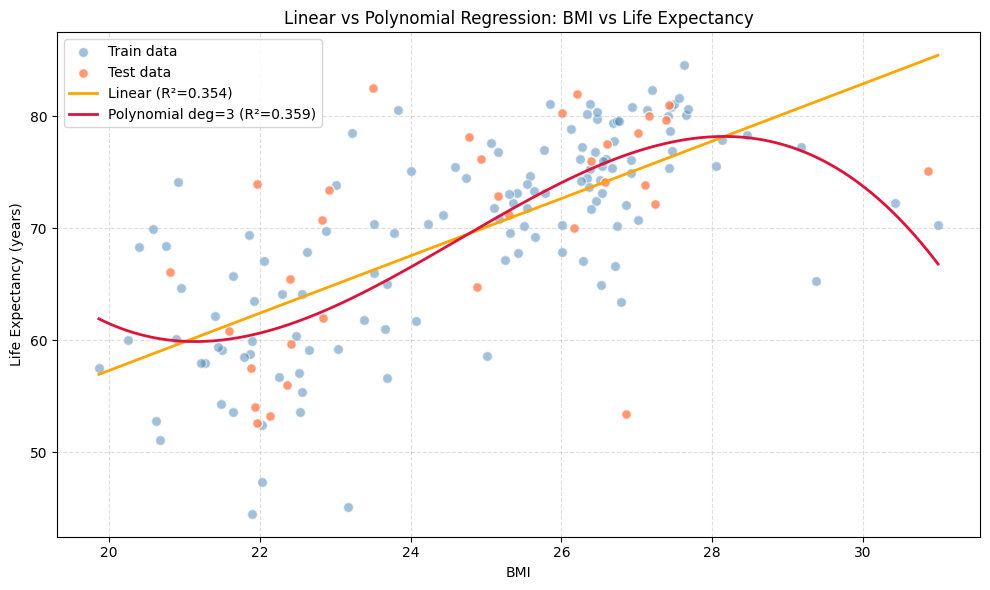

In [14]:
print('=== TEST SET ===')
r2_linear_test = evaluate('Linear Regression', model_linear, X_test, y_test)
print()
r2_poly_test   = evaluate('Polynomial Regression (deg=3)', model_poly, X_test, y_test)
print()
winner = 'Polynomial' if r2_poly_test > r2_linear_test else 'Linear'
print(f'>>> Better on TEST: {winner} model')
print()
print('--- Summary ---')
print(f'Linear    — Train R²: {r2_linear_train:.4f}  |  Test R²: {r2_linear_test:.4f}')
print(f'Polynomial— Train R²: {r2_poly_train:.4f}  |  Test R²: {r2_poly_test:.4f}')
print()
print('Conclusion: The Polynomial model better captures the non-linear curved')
print('relationship between BMI and Life Expectancy, scoring higher R² on both sets.')
print('A straight line underfits this data; the curve fits the pattern much better.')
print()

# --- Bonus: Visual comparison ---
x_line = np.linspace(X['BMI'].min(), X['BMI'].max(), 300).reshape(-1, 1)
y_linear = model_linear.predict(x_line)
y_poly   = model_poly.predict(x_line)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='steelblue', alpha=0.5, s=50, label='Train data', edgecolors='white')
plt.scatter(X_test,  y_test,  color='coral',     alpha=0.8, s=50, label='Test data',  edgecolors='white')
plt.plot(x_line, y_linear, color='orange',   linewidth=2, label=f'Linear (R²={r2_linear_test:.3f})')
plt.plot(x_line, y_poly,   color='crimson',  linewidth=2, label=f'Polynomial deg=3 (R²={r2_poly_test:.3f})')
plt.xlabel('BMI')
plt.ylabel('Life Expectancy (years)')
plt.title('Linear vs Polynomial Regression: BMI vs Life Expectancy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()